# CS 6220 - Homework 1

## Iris Flower Classification

This notebook implements a machine learning pipeline using the Iris flower dataset and scikit-learn. It uses a Logistic Regression Classifier.

### Step 1: Import Libraries

This step imports all the necessary Python libraries.
- `pandas` is used for data manipulation.
- `matplotlib` and `seaborn` are used for data visualization.
- `sklearn` (scikit-learn) provides the machine learning tools, including data splitting, preprocessing, and the Logistic Regression model.

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

### Step 2: Load the Dataset

The Iris dataset is loaded from the local `iris.data` file into a Pandas DataFrame. Since the raw data file doesn't contain header names, the column names are manually assigned: `sepal_length`, `sepal_width`, `petal_length`, `petal_width`, and `class`. The first few rows are displayed.

In [2]:
# Load the iris dataset
url = 'iris.data'
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
iris_df = pd.read_csv(url, header=None, names=column_names)
display(iris_df.head())


,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### Step 3: Data Exploration

To understand the data. This step includes:
1. Printing the dataset's basic info.
2. Generating summary statistics (mean, min, max, etc.) for the numerical features.
3. Checking the class distribution to ensure the dataset is balanced.
4. Creating a pairplot using Seaborn to visually explore the relationships between different features, colored by class.

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Summary Statistics:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Class Distribution:
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


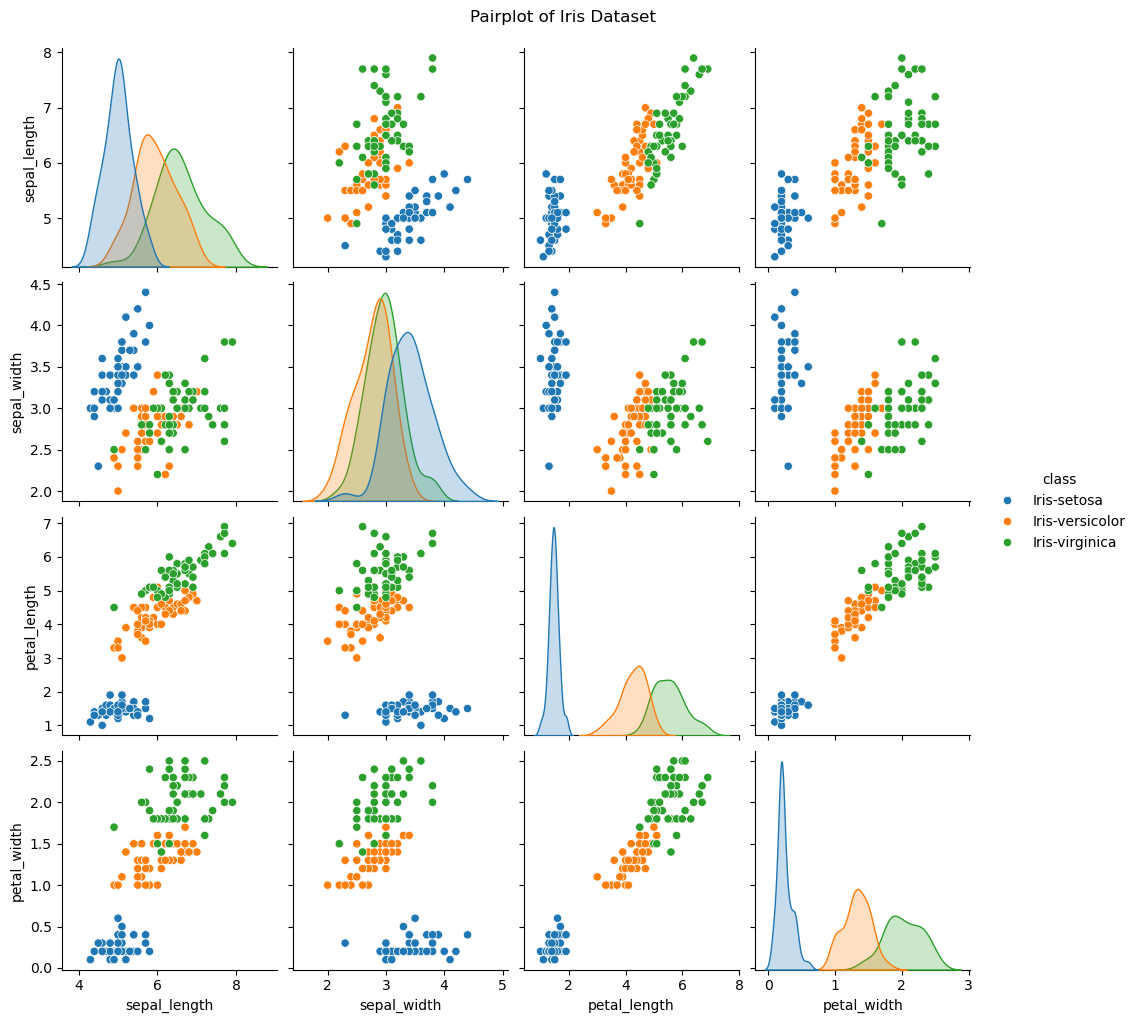

In [3]:
# Display basic info and summary statistics
print('Dataset Info:')
iris_df.info()
print('\nSummary Statistics:')
display(iris_df.describe())
print('\nClass Distribution:')
print(iris_df['class'].value_counts())

# Scatterplot
sns.pairplot(iris_df, hue='class')
plt.suptitle('Pairplot of Iris Dataset', y=1.02)
plt.show()

### Step 4: Train-Test Split

 Here, the features (`X`) are separated from the target labels (`y`). Then, using scikit-learn's `train_test_split`, the dataset is divided so that 80% is used for training the model, and the remaining 20% is used for testing accuracy.

In [4]:
# Split dataset into features and target
X = iris_df.drop('class', axis=1)
y = iris_df['class']

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Step 5: Helper Functions

To keep the code organized, a helper function is created to evaluate model performance. It calculates both accuracy and the confusion matrix.

In [5]:
def evaluate_model(y_true, y_pred):
    '''
    Calculates accuracy and confusion matrix.
    Inputs: y_true (actual labels), y_pred (predicted labels)
    Outputs: accuracy_score, confusion_matrix
    '''
    acc = accuracy_score(y_true, y_pred)
    conf_matrix = confusion_matrix(y_true, y_pred)
    return acc, conf_matrix

### Test Helper Function

This cell tests the `evaluate_model` function with dummy inputs to verify expected outputs.

In [6]:
# Test inputs
test_y_true = [0, 1, 0, 1, 2]
test_y_pred = [0, 1, 1, 1, 2]

test_acc, test_conf = evaluate_model(test_y_true, test_y_pred)
print(f'Test Accuracy: {test_acc}')
print('Test Confusion Matrix:')
print(test_conf)

Test Accuracy: 0.8
Test Confusion Matrix:
[[1 1 0]
 [0 2 0]
 [0 0 1]]


### Step 6: Data Preprocessing (Scaling)

Scaling the features using `StandardScaler`. 

In [7]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

# Inspect intermediate results (first 5 rows of scaled training data)
print('First 5 rows of scaled X_train:')
print(X_train_scaled[:5])

First 5 rows of scaled X_train:
[[-1.47393679  1.22037928 -1.5639872  -1.30948358]
 [-0.13307079  3.02001693 -1.27728011 -1.04292204]
 [ 1.08589829  0.09560575  0.38562104  0.28988568]
 [-1.23014297  0.77046987 -1.21993869 -1.30948358]
 [-1.7177306   0.32056046 -1.39196294 -1.30948358]]


### Step 7: Train the Model

The Logistic Regression model is initialized and trained on the scaled training data. Execution time is recorded.

In [8]:
import time

# Initialize model
log_reg = LogisticRegression(random_state=42)

# Time the training process
start_time = time.time()
log_reg.fit(X_train_scaled, y_train)
train_time_lr = time.time() - start_time

print(f'Logistic Regression Training Time: {train_time_lr:.6f} seconds')

Logistic Regression Training Time: 0.012001 seconds


### Step 8: Test the Model

The trained model is used to predict the classes of the scaled test data. Testing time is also recorded.

In [9]:
# Time the testing process
start_time = time.time()
y_pred_lr = log_reg.predict(X_test_scaled)
test_time_lr = time.time() - start_time

print(f'Logistic Regression Testing Time: {test_time_lr:.6f} seconds')
print('Predictions:')
print(y_pred_lr[:10]) # shows first 10 predictions

Logistic Regression Testing Time: 0.001170 seconds
Predictions:
['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor']


### Step 9: Evaluate the Model

The helper function created earlier is used to evaluate the model's performance on the test set.

In [10]:
# Using helper function to evaluate
acc_lr, conf_matrix_lr = evaluate_model(y_test, y_pred_lr)

print(f'Logistic Regression Accuracy: {acc_lr:.4f}')
print('Confusion Matrix:')
print(conf_matrix_lr)

Logistic Regression Accuracy: 1.0000
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
